In [2]:
import buddy
import spot

# from commonroad_reach_semantic.data_structure.model_checking.finite_automaton import FiniteAutomaton

spot.setup()

In [31]:
formula = spot.from_ltlf("(a | !b) U G c")
formula

spot.formula("alive & (alive U G!alive) & ((a | !b) U (alive & G(!alive | c)))")

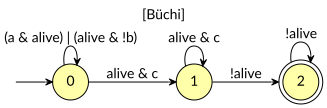

In [32]:
aut = formula.translate(xargs='simul=0')
bdict = aut.get_dict()
aut

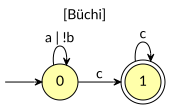

In [33]:
finite_aut = spot.to_finite(aut)
finite_aut

In [5]:
init = finite_aut.get_init_state_number()
init

0

In [6]:
for edge1 in finite_aut.out(init):
    # will be in DNF --> bbd_to_formula computes an irredundant sum of products
    # https://spot.lre.epita.fr/doxygen/namespacespot.html#aba9b9efe994006c29a6d77da94897df8
    cond_formula = spot.bdd_to_formula(edge1.cond, bdict)
    print(cond_formula)
    for child in cond_formula:
        print(f"  * {child}")

!a
  * a
a


In [7]:
def disjuncts(f):
    if f._is(spot.op_Or):
        for child in f:
            yield child
    else:
        yield f

In [8]:
def conjuncts(f):
    if f._is(spot.op_And):
        for child in f:
            yield child
    else:
        yield f

In [9]:
def extract_atomic_proposition(f):
    if f._is(spot.op_Not) and f[0]._is(spot.op_ap):
        return f[0].ap_name(), True
    elif f._is(spot.op_ap):
        return f.ap_name(), False
    else:
        raise ValueError(f"{f} is not a (negated) literal")

In [10]:
def dnf_formula_to_minterms(f):
    try:
        return [
            [extract_atomic_proposition(c) for c in conjuncts(d)]
            for d in disjuncts(f)
        ]
    except ValueError as err:
        raise ValueError(f"Formula {f} is not in DNF: {err}")

In [11]:
phi = spot.formula("(a & b) | (!c & d)")
dnf_formula_to_minterms(phi)

[[('a', False), ('b', False)], [('c', True), ('d', False)]]

In [12]:
def iterate_nfa(automaton):
    bdict = automaton.get_dict()
    to_visit = [automaton.get_init_state_number()]
    visited = []
    while to_visit:
        current_state = to_visit.pop()
        visited.append(current_state)
        print(f"State {current_state} is{' not' if not automaton.state_is_accepting(current_state) else ''} accepting")
        for edge in automaton.out(current_state):
            condition_formula = spot.bdd_to_formula(edge.cond, bdict)
            # will be in DNF --> bbd_to_formula computes an irredundant sum of products
            # https://spot.lre.epita.fr/doxygen/namespacespot.html#aba9b9efe994006c29a6d77da94897df8
            minterms = dnf_formula_to_minterms(condition_formula)
            for minterm in minterms:
                print(f"Edge to {edge.dst} with constraints {minterm}")
            if edge.dst not in visited and edge.dst not in to_visit:
                to_visit.append(edge.dst)

In [13]:
iterate_nfa(finite_aut)

State 0 is not accepting
Edge to 1 with constraints [('a', True)]
Edge to 2 with constraints [('a', False)]
State 2 is not accepting
Edge to 1 with constraints [('a', True), ('b', False)]
Edge to 2 with constraints [('a', False), ('b', False)]
State 1 is accepting
Edge to 1 with constraints [('a', True)]
Edge to 2 with constraints [('a', False)]


In [14]:
finite_aut.state_is_accepting(1)

True

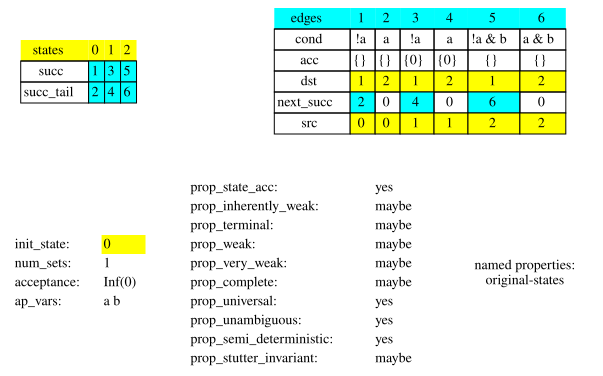

In [15]:
finite_aut.show_storage()

In [16]:
for edge in finite_aut.edges():
    print(edge.src)

0
0
1
1
2
2


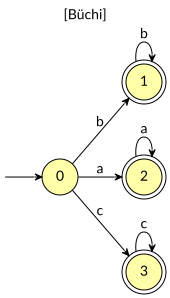

In [17]:
aut2 = spot.to_finite(spot.from_ltlf("G a | G b | G c").translate(xargs='simul=0'))
# aut2 = spot.translate("G a | G b | G c", xargs="simul=0")
aut2

In [18]:
fa = FiniteAutomaton("G (a -> X[!] b)")
for dst, minterms in fa.transitions_from({1, 2}):
    print(f"Edge to {dst} with constraints {minterms}")

Edge to 1 with constraints [[('a', True)]]
Edge to 2 with constraints [[('a', False)]]
